# Analysis performed on the morphological reconstructions data of human and mouse

In [1]:
import glob
import os
import tmd
import pandas
import numpy as np
import matplotlib.pyplot as plt
from morph_tool import morphdb
import neurom as nm
from tmd import view
import seaborn

In [2]:
# Define paths to datasets
dfH = morphdb.MorphDB.from_neurondb('../MorphologyData/Human/zero_diameter_release/h5/neurondb.xml').df
dfR = morphdb.MorphDB.from_neurondb('../MorphologyData/Rat/04_ZeroDiameterFix-h5/neurondb.xml').df

#### Group morphologies from layers 2 and 3

In [3]:
Hl23_df = dfH.loc[dfH['mtype'].isin(['L2_PC', 'L2_STPC', 'L2_PTPC', 'L3_PC', 'L3_STPC', 'L3_PTPC'])]
Hl23_df_axons = dfH.loc[dfH['use_axon'] == True].loc[dfH['mtype'].isin(['L2_PC', 'L2_STPC', 'L2_PTPC', 'L3_PC', 'L3_STPC', 'L3_PTPC'])]

Rl23_df = dfR.loc[dfR['mtype'].isin(['L2_IPC', 'L2_TPC:A', 'L2_TPC:B', 'L3_TPC:A', 'L3_TPC:C'])]
Rl23_df_axons = dfR.loc[dfR['use_axon'] == True].loc[dfR['mtype'].isin(['L2_IPC', 'L2_TPC:A', 'L2_TPC:B', 'L3_TPC:A', 'L3_TPC:C'])]

print('Human L23 PC:', len(Hl23_df), ' \nRat L23 PC:', len(Rl23_df))

Human L23 PC: 366  
Rat L23 PC: 103


In [4]:
print('Human L23 PC:', len(Hl23_df_axons), ' \nRat L23 PC:', len(Rl23_df_axons))

Human L23 PC: 78  
Rat L23 PC: 68


#### Group morphologies from layer 4

In [5]:
Hl4_df = dfH.loc[dfH['mtype'].isin(['L4_PC', 'L45_PC'])]
Hl4_df_axons = dfH.loc[dfH['use_axon'] == True].loc[dfH['mtype'].isin(['L4_PC', 'L45_PC'])]

Rl4_df = dfR.loc[dfR['mtype'].isin(['L4_UPC', 'L4_TPC'])]
Rl4_df_axons = dfR.loc[dfR['use_axon'] == True].loc[dfR['mtype'].isin(['L4_UPC', 'L4_TPC'])]

print('Human L4 PC:', len(Hl4_df), ' \nRat L4 PC:', len(Rl4_df))

Human L4 PC: 37  
Rat L4 PC: 70


#### Group morphologies from layers 5 and 6

In [6]:
Hl56_df = dfH.loc[dfH['mtype'].isin(['L5_PC', 'L56_PC', 'L6_PC'])]
Hl56_df_axons = dfH.loc[dfH['use_axon'] == True].loc[dfH['mtype'].isin(['L5_PC', 'L56_PC', 'L6_PC'])]

Rl56_df = dfR.loc[dfR['mtype'].isin(['L5_UPC', 'L5_TPC:A', 'L5_TPC:B', 'L5_TPC:C', 'L6_UPC', 'L6_TPC:A', 'L6_TPC:B', 'L6_TPC:C', 'L6_BPC', 'L6_IPC', 'L6_HPC'])]
Rl56_df_axons = dfR.loc[dfR['use_axon'] == True].loc[dfR['mtype'].isin(['L5_UPC', 'L5_TPC:A', 'L5_TPC:B', 'L5_TPC:C', 'L6_UPC', 'L6_TPC:A', 'L6_TPC:B', 'L6_TPC:C', 'L6_BPC', 'L6_IPC', 'L6_HPC'])]

print('Human L5 PC:', len(Hl56_df), ' \nRat L5 PC:', len(Rl56_df))

Human L5 PC: 95  
Rat L5 PC: 289


#### Group morphologies for inhibitory neurons

In [7]:
Hl_IN_df = dfH.loc[dfH['mtype'].isin(['BC', 'IN'])]
Hl_IN_df_axons = dfH.loc[dfH['use_axon'] == True].loc[dfH['mtype'].isin(['BC', 'IN'])]

Rl_IN_df = dfR.loc[dfR['mtype'].isin([
       'L1_DAC', 'L1_HAC', 'L1_LAC', 'L1_NGC-DA', 'L1_NGC-SA', 'L1_SAC',
       'L23_BP', 'L23_BTC', 'L23_CHC', 'L23_DBC', 'L23_LBC', 'L23_MC','L23_NBC', 'L23_NGC', 'L23_SBC',
       'L4_BP', 'L4_BTC', 'L4_CHC', 'L4_DBC','L4_LBC', 'L4_MC', 'L4_NBC', 'L4_NGC', 'L4_SBC', 
       'L5_BP', 'L5_BTC', 'L5_CHC', 'L5_DBC','L5_LBC', 'L5_MC', 'L5_NBC', 'L5_SBC',
       'L6_BTC', 'L6_CHC', 'L6_DBC','L6_LBC', 'L6_MC', 'L6_NBC', 'L6_NGC','L6_SBC'])]
Rl_IN_df_axons= dfR.loc[dfR['use_axon'] == True].loc[dfR['mtype'].isin([
       'L1_DAC', 'L1_HAC', 'L1_LAC', 'L1_NGC-DA', 'L1_NGC-SA', 'L1_SAC',
       'L23_BP', 'L23_BTC', 'L23_CHC', 'L23_DBC', 'L23_LBC', 'L23_MC','L23_NBC', 'L23_NGC', 'L23_SBC',
       'L4_BP', 'L4_BTC', 'L4_CHC', 'L4_DBC','L4_LBC', 'L4_MC', 'L4_NBC', 'L4_NGC', 'L4_SBC', 
       'L5_BP', 'L5_BTC', 'L5_CHC', 'L5_DBC','L5_LBC', 'L5_MC', 'L5_NBC', 'L5_SBC',
       'L6_BTC', 'L6_CHC', 'L6_DBC','L6_LBC', 'L6_MC', 'L6_NBC', 'L6_NGC','L6_SBC'])]

print('Human IN:', len(Hl_IN_df), ' \nRat IN:', len(Rl_IN_df))

Human IN: 80  
Rat IN: 661


### Load the morphologies of the groups

In [8]:
popH = {'l23': tmd.io.load_population(Hl23_df['path'].tolist(), use_morphio=True),
        'l4': tmd.io.load_population(Hl4_df['path'].tolist(), use_morphio=True),
        'l56': tmd.io.load_population(Hl56_df['path'].tolist(), use_morphio=True),
        'lin': tmd.io.load_population(Hl_IN_df['path'].tolist(), use_morphio=True)}

In [9]:
popH_axons = {'l23': tmd.io.load_population(Hl23_df_axons['path'].tolist(), use_morphio=True),
              'l4': tmd.io.load_population(Hl4_df_axons['path'].tolist(), use_morphio=True),
              'l56': tmd.io.load_population(Hl56_df_axons['path'].tolist(), use_morphio=True),
              'lin': tmd.io.load_population(Hl_IN_df_axons['path'].tolist(), use_morphio=True)}

In [10]:
popR = {'l23': tmd.io.load_population([l for l in Rl23_df['path'].tolist() if l is not None ], use_morphio=True),
        'l4': tmd.io.load_population(Rl4_df['path'].tolist(), use_morphio=True),
        'l56': tmd.io.load_population(Rl56_df['path'].tolist(), use_morphio=True),
        'lin': tmd.io.load_population(Rl_IN_df['path'].tolist(), use_morphio=True)}

In [11]:
popR_axons = {'l23': tmd.io.load_population([l for l in Rl23_df_axons['path'].tolist() if l is not None ], use_morphio=True),
        'l4': tmd.io.load_population(Rl4_df_axons['path'].tolist(), use_morphio=True),
        'l56': tmd.io.load_population(Rl56_df_axons['path'].tolist(), use_morphio=True),
        'lin': tmd.io.load_population(Rl_IN_df_axons['path'].tolist(), use_morphio=True)}

In [12]:
popH_nm = {'l23': nm.load_morphologies(Hl23_df['path'].tolist()),
           'l4': nm.load_morphologies(Hl4_df['path'].tolist()),
           'l56': nm.load_morphologies(Hl56_df['path'].tolist()),
           'lin': nm.load_morphologies(Hl_IN_df['path'].tolist())}

In [13]:
popH_nm_axons = {'l23': nm.load_morphologies(Hl23_df_axons['path'].tolist()),
           'l4': nm.load_morphologies(Hl4_df_axons['path'].tolist()),
           'l56': nm.load_morphologies(Hl56_df_axons['path'].tolist()),
           'lin': nm.load_morphologies(Hl_IN_df_axons['path'].tolist())}

In [14]:
popR_nm = {'l23': nm.load_morphologies([l for l in Rl23_df['path'].tolist() if l is not None ]),
           'l4': nm.load_morphologies(Rl4_df['path'].tolist()),
           'l56': nm.load_morphologies(Rl56_df['path'].tolist()),
           'lin': nm.load_morphologies(Rl_IN_df['path'].tolist())}

In [15]:
popR_nm_axons = {'l23': nm.load_morphologies([l for l in Rl23_df_axons['path'].tolist() if l is not None ]),
           'l4': nm.load_morphologies(Rl4_df_axons['path'].tolist()),
           'l56': nm.load_morphologies(Rl56_df_axons['path'].tolist()),
           'lin': nm.load_morphologies(Rl_IN_df_axons['path'].tolist())}

### Define some useful functions

In [16]:
def rotate_xz(coords, theta):
    """
    Rotate a list of 3D coordinates in the x-z plane (around the y-axis) by angle theta (in radians).
    
    Parameters:
        coords (list of tuples): List of (x, y, z) coordinates.
        theta (float): Angle in radians.
        
    Returns:
        list of tuples: Rotated coordinates.
    """
    # Rotation matrix around y-axis
    R = np.array([
        [np.cos(theta), 0, np.sin(theta)],
        [0,            1, 0           ],
        [-np.sin(theta), 0, np.cos(theta)]
    ])
    
    rotated_coords = []
    for x, y, z in coords:
        v = np.array([x, y, z])
        v_rotated = R @ v
        rotated_coords.append(tuple(v_rotated))
        
    return rotated_coords

In [17]:
def find_number_bins(X, Y, bin_size=50):
    """Returns the number of bins to adjust the bin size"""
    return (int((np.max(X) - np.min(X)) / bin_size), int((np.max(Y) - np.min(Y)) / bin_size))

def compute_density(n_list, bin_size, ranges=[[-1000, 1000], [-500, 500]]):
    Y = np.concatenate([tr.y for tr in n_list])
    X = np.concatenate([tr.x for tr in n_list])

    if ranges is None:
        binsX, binsY = find_number_bins(X, Y, bin_size)
    else:
        binsX, binsY = find_number_bins(ranges[0], ranges[1], bin_size)

    V, Vx, Vy = np.histogram2d(Y, X, bins=(binsX, binsY), range=ranges)

    return (V / np.max(V), Vx, Vy)

def extract_hist(neuron, bin_size, ranges=[[-1000, 1000], [-500, 500]]):
    return compute_density(neuron.dendrites, bin_size=bin_size, ranges=ranges)

def extract_hist_axon(neuron, bin_size, ranges=[[-1000, 1000], [-500, 500]]):
    return compute_density(neuron.axon, bin_size=bin_size, ranges=ranges)

def extract_hist_pop(population, bin_size, ranges=[[-1000, 1000], [-500, 500]]):

    VALL = []
    for neuron in population.neurons:
        V, Vx, Vy = compute_density(neuron.dendrites, bin_size=bin_size, ranges=ranges)
        VALL.append(V)
    
    return VALL, Vx, Vy

def extract_hist_pop_axon(population, bin_size, ranges=[[-1000, 1000], [-500, 500]]):

    VALL = []
    for neuron in population.neurons:
        V, Vx, Vy = compute_density(neuron.axon, bin_size=bin_size, ranges=ranges)
        VALL.append(V)
    
    return VALL, Vx, Vy

In [18]:
def compute_density_rotate(n_list, bin_size, ranges=[[-1000, 1000], [-500, 500]], angle=2*np.pi):
    X = np.concatenate([tr.x for tr in n_list])
    Y = np.concatenate([tr.y for tr in n_list])
    Z = np.concatenate([tr.z for tr in n_list])

    rotated_coords = rotate_xz([[i,j,k] for (i,j,k) in zip(X,Y,Z)], theta=angle)
    
    X, Y, _ = np.transpose(rotated_coords)

    if ranges is None:
        binsX, binsY = find_number_bins(X, Y, bin_size)
    else:
        binsX, binsY = find_number_bins(ranges[0], ranges[1], bin_size)

    V, Vx, Vy = np.histogram2d(Y, X, bins=(binsX, binsY), range=ranges)

    return (V / np.max(V), Vx, Vy)


def extract_histR(neuron, bin_size, ranges=[[-1000, 1000], [-500, 500]]):
    return compute_density(neuron.dendrites, bin_size=bin_size, ranges=ranges)

def extract_hist_axonR(neuron, bin_size, ranges=[[-1000, 1000], [-500, 500]]):
    return compute_density(neuron.axon, bin_size=bin_size, ranges=ranges)

def extract_hist_popR(population, bin_size, ranges=[[-1000, 1000], [-500, 500]], rotations=100):

    VALL = []

    for neuron in population.neurons:
        for _ in np.arange(rotations):
            V, Vx, Vy = compute_density_rotate(neuron.dendrites, bin_size=bin_size, ranges=ranges, angle=2*np.pi*np.random.random())
            VALL.append(V)
    
    return VALL, Vx, Vy

def extract_hist_pop_axonR(population, bin_size, ranges=[[-1000, 1000], [-500, 500]], rotations=100):

    VALL = []

    for neuron in population.neurons:
        for _ in np.arange(rotations):
            V, Vx, Vy = compute_density_rotate(neuron.axon, bin_size=bin_size, ranges=ranges, angle=2*np.pi*np.random.random())
            VALL.append(V)
    
    return VALL, Vx, Vy

In [55]:
def compute_density_MR(n_list, bin_size, ranges=[[-1000, 1000], [-500, 500]]):
    X = np.concatenate([tr.x for tr in n_list])
    Y = np.concatenate([tr.y for tr in n_list])
    Z = np.concatenate([tr.z for tr in n_list])

    C1 = np.sqrt(X**2 + Z**2)

    #print(C1)

    #rotated_coords = rotate_xz([[i,j,k] for (i,j,k) in zip(X,Y,Z)], theta=angle)
    
    #X, Y, _ = np.transpose(rotated_coords)

    if ranges is None:
        binsX, binsY = find_number_bins(C1, Y, bin_size)
    else:
        binsX, binsY = find_number_bins(ranges[0], ranges[1], bin_size)

    V, Vx, Vy = np.histogram2d(Y, C1, bins=(binsX, binsY), range=ranges)

    return (V / np.max(V), Vx, Vy)

def extract_hist_popMR(population, bin_size, ranges=[[-1000, 1000], [-500, 500]]):

    VALL = []

    for neuron in population.neurons:
        for _ in np.arange(rotations):
            V, Vx, Vy = compute_density_MR(neuron.dendrites, bin_size=bin_size, ranges=ranges)
            VALL.append(V)
    
    return VALL, Vx, Vy

def extract_hist_pop_axonMR(population, bin_size, ranges=[[-1000, 1000], [-500, 500]]):

    VALL = []

    for neuron in population.neurons:
        for _ in np.arange(rotations):
            V, Vx, Vy = compute_density_MR(neuron.axon, bin_size=bin_size, ranges=ranges)
            VALL.append(V)
    
    return VALL, Vx, Vy

# Figure 5 Non-random formation of multiple touches and morphological variability explain network complexity

B) Morphological analysis of human (top, teal) versus rat (bottom, purple) pyramidal cells. 
The morphologies of dendrites (and axons) were randomly rotated (20 times) and projected to x-y plane to generate a density cloud of each neuron. 
The standard deviation over the mean density cloud for the population of (366 human and 103 rat) dendrites (left) and (78 human and 68 rat) axons (middle).

## As well as, Figure S9 Density clouds of neurites in space. 
Dendrites and axons were randomly rotated
(20 times) and projected to x-y plane to generate a density cloud of each neuron. From this it was
computed: the Average (top), standard deviation (middle) and coefficient of variation (bottom) for
dendrites (left) and axons (right)

In [35]:
rotations = 20

bin_size = 88

ranges = [[-1600, 1600], [-1200, 1200]]

VH, VHx, VHy = extract_hist_popR(popH['l23'], bin_size, ranges=ranges, rotations=rotations)
VHA, VHAx, VHAy = extract_hist_pop_axonR(popH_axons['l23'], bin_size, ranges=ranges, rotations=rotations)

bin_size = 50

V, Vx, Vy = extract_hist_popR(popR['l23'], bin_size, ranges=ranges, rotations=rotations)
VA, VAx, VAy = extract_hist_pop_axonR(popR_axons['l23'], bin_size, ranges=ranges, rotations=rotations)

VH2, VHx2, VHy2 = extract_hist_popR(popH['l23'], bin_size, ranges=ranges, rotations=rotations)
VHA2, VHAx2, VHAy2 = extract_hist_pop_axonR(popH_axons['l23'], bin_size, ranges=ranges, rotations=rotations)

In [66]:
bin_size = 88

ranges = [[-1600, 1600], [0, 1200]]

VH_MR, VHx_MR, VHy_MR = extract_hist_popMR(popH['l23'], bin_size, ranges=ranges)
VHA_MR, VHAx_MR, VHAy_MR = extract_hist_pop_axonMR(popH_axons['l23'], bin_size, ranges=ranges)

bin_size = 50

V_MR, Vx_MR, Vy_MR = extract_hist_popMR(popR['l23'], bin_size, ranges=ranges)
VA_MR, VAx_MR, VAy_MR = extract_hist_pop_axonMR(popR_axons['l23'], bin_size, ranges=ranges)

VH2_MR, VHx2_MR, VHy2_MR = extract_hist_popMR(popH['l23'], bin_size, ranges=ranges)
VHA2_MR, VHAx2_MR, VHAy2_MR = extract_hist_pop_axonMR(popH_axons['l23'], bin_size, ranges=ranges)

/var/folders/hk/mjws_41j5kg27jkqhyz5ngt42_k7l5/T/ipykernel_8205/1630069044.py:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax1.pcolor(VHy[:-1], VHx[:-1], D , cmap=cmap)
/var/folders/hk/mjws_41j5kg27jkqhyz5ngt42_k7l5/T/ipykernel_8205/1630069044.py:17: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax1.pcolor(VHy[:-1], VHx[:-1], D , cmap=cmap)
/var/folders/hk/mjws_41j5kg27jkqhyz5ngt42_k7l5/T/ipykernel_8205/1630069044.py:22: RuntimeWarning: invalid value en

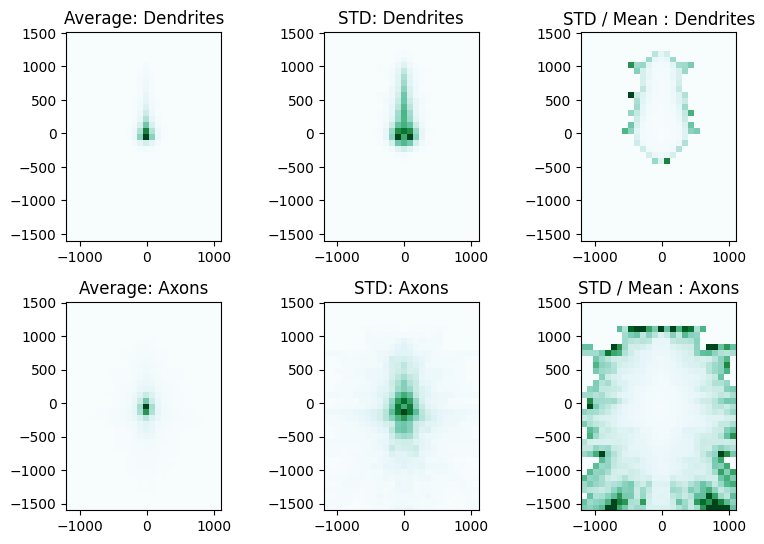

In [46]:
# HUMAN
fig = plt.figure(figsize=(8,8))

cmap = plt.cm.BuGn

#vmin, vmax = 0, 0.5

D = np.mean(VH, axis=0)
 
ax1 = fig.add_subplot(331)
ax1.pcolor(VHy[:-1], VHx[:-1], D , cmap=cmap)
ax1.set_aspect('equal')
plt.title('Average: Dendrites')

D = np.std(VH, axis=0)
 
ax1 = fig.add_subplot(332)
ax1.pcolor(VHy[:-1], VHx[:-1], D , cmap=cmap)
ax1.set_aspect('equal')
plt.title('STD: Dendrites')


D = np.std(VH, axis=0) / np.mean(VH, axis=0)
D = np.nan_to_num(D)

ax1 = fig.add_subplot(333)
ax1.pcolor(VHy[:-1], VHx[:-1], D , cmap=cmap)
ax1.set_aspect('equal')
plt.title('STD / Mean : Dendrites')

D = np.mean(VHA, axis=0)
 
ax1 = fig.add_subplot(334)
ax1.pcolor(VHy[:-1], VHx[:-1], D , cmap=cmap)
ax1.set_aspect('equal')
plt.title('Average: Axons')

D = np.std(VHA, axis=0)
 
ax1 = fig.add_subplot(335)
ax1.pcolor(VHy[:-1], VHx[:-1], D , cmap=cmap)
ax1.set_aspect('equal')
plt.title('STD: Axons')


D = np.std(VHA, axis=0) / np.mean(VHA, axis=0)
D = np.nan_to_num(D)

ax1 = fig.add_subplot(336)
ax1.pcolor(VHy[:-1], VHx[:-1], D , cmap=cmap)
ax1.set_aspect('equal')
plt.title('STD / Mean : Axons')

plt.tight_layout()

/var/folders/hk/mjws_41j5kg27jkqhyz5ngt42_k7l5/T/ipykernel_8205/1642060698.py:10: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax1.pcolor(Vy[:-1], Vx[:-1], D , cmap=cmap)
/var/folders/hk/mjws_41j5kg27jkqhyz5ngt42_k7l5/T/ipykernel_8205/1642060698.py:17: MatplotlibDeprecationWarning: shading='flat' when X and Y have the same dimensions as C is deprecated since 3.3.  Either specify the corners of the quadrilaterals with X and Y, or pass shading='auto', 'nearest' or 'gouraud', or set rcParams['pcolor.shading'].  This will become an error two minor releases later.
  ax1.pcolor(Vy[:-1], Vx[:-1], D , cmap=cmap)
/var/folders/hk/mjws_41j5kg27jkqhyz5ngt42_k7l5/T/ipykernel_8205/1642060698.py:22: RuntimeWarning: invalid value encoun

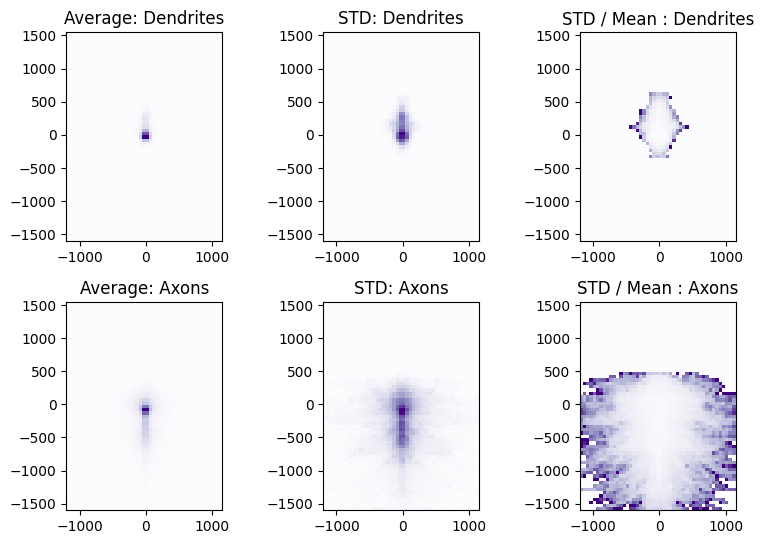

In [42]:
# RAT
fig = plt.figure(figsize=(8,8))

cmap = plt.cm.Purples

#vmin, vmax = 0, 0.5

D = np.mean(V, axis=0)
 
ax1 = fig.add_subplot(331)
ax1.pcolor(Vy[:-1], Vx[:-1], D , cmap=cmap)
ax1.set_aspect('equal')
plt.title('Average: Dendrites')

D = np.std(V, axis=0)
 
ax1 = fig.add_subplot(332)
ax1.pcolor(Vy[:-1], Vx[:-1], D , cmap=cmap)
ax1.set_aspect('equal')
plt.title('STD: Dendrites')


D = np.std(V, axis=0) / np.mean(V, axis=0)
D = np.nan_to_num(D)

ax1 = fig.add_subplot(333)
ax1.pcolor(Vy[:-1], Vx[:-1], D , cmap=cmap)
ax1.set_aspect('equal')
plt.title('STD / Mean : Dendrites')

D = np.mean(VA, axis=0)
 
ax1 = fig.add_subplot(334)
ax1.pcolor(Vy[:-1], Vx[:-1], D , cmap=cmap)
ax1.set_aspect('equal')
plt.title('Average: Axons')

D = np.std(VA, axis=0)
 
ax1 = fig.add_subplot(335)
ax1.pcolor(Vy[:-1], Vx[:-1], D , cmap=cmap)
ax1.set_aspect('equal')
plt.title('STD: Axons')


D = np.std(VA, axis=0) / np.mean(VA, axis=0)
D = np.nan_to_num(D)

ax1 = fig.add_subplot(336)
ax1.pcolor(Vy[:-1], Vx[:-1], D , cmap=cmap)
ax1.set_aspect('equal')
plt.title('STD / Mean : Axons')

plt.tight_layout()


#plt.savefig('../Figs/ForNatali/Rat_density_cloud.png')
#plt.savefig('../Figs/ForNatali/Rat_density_cloud.eps')
#plt.savefig('../Figs/ForNatali/Rat_density_cloud.svg')



In [20]:
bns = np.linspace(0, 2000, 300)

In [21]:
################### Apicals ################### 

phsR = [tmd.methods.get_persistence_diagram(p) for p in popR['l23'].apical_dendrite]
phsH = [tmd.methods.get_persistence_diagram(p) for p in popH['l23'].apical_dendrite]
entrH = [tmd.vectorizations.life_entropy_curve(p, bns)[0] for p in phsH]
entrR = [tmd.vectorizations.life_entropy_curve(p, bns)[0] for p in phsR]

In [22]:
################### Dendrites ################### 

phsRD = [tmd.methods.get_persistence_diagram(p) for p in popR['l23'].dendrites]
phsHD = [tmd.methods.get_persistence_diagram(p) for p in popH['l23'].dendrites]
entrHD = [tmd.vectorizations.life_entropy_curve(p, bns)[0] for p in phsHD]
entrRD = [tmd.vectorizations.life_entropy_curve(p, bns)[0] for p in phsRD]

In [23]:
################### Axons ################### 

phsRA = [tmd.methods.get_persistence_diagram(p) for p in popR_axons['l23'].axon]
phsHA = [tmd.methods.get_persistence_diagram(p) for p in popH_axons['l23'].axon]
entrHA = [tmd.vectorizations.life_entropy_curve(p, bns)[0] for p in phsHA]
entrRA = [tmd.vectorizations.life_entropy_curve(p, bns)[0] for p in phsRA]

# Figure S10 (Human) and S11 (Rat) Central objects of the TMD pipeline.
Dendritic tree structure of an exemplar human pyramidal neuron (top left). Persistent analysis from Kanari et al. 2025: bar-code (top right), diagram (bottom left) and image (bottom right)

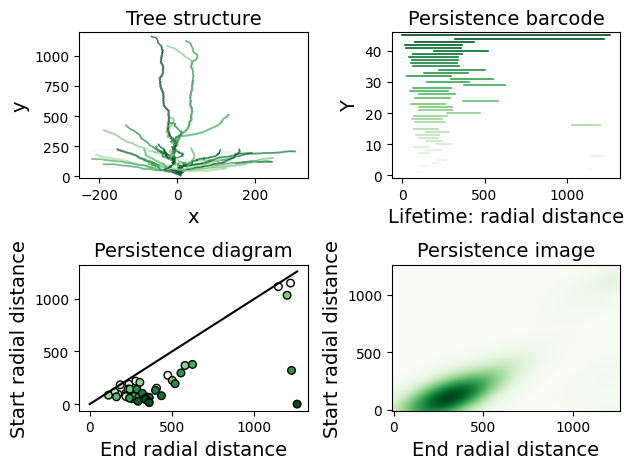

In [25]:
# Human
view.view.tree_full_persistence_colors(popH['l23'].apical_dendrite[2], cmap=plt.cm.Greens)
plt.tight_layout()

# Rat (uncomment following 2 lines to run)
#view.view.tree_full_persistence_colors(popR['l23'].apical_dendrite[2], cmap=plt.cm.Purples)
#plt.tight_layout()

#plt.savefig('../Figs/Example_topology.png')
#plt.savefig('../Figs/Example_topology.eps')
#plt.savefig('../Figs/Example_topology.svg')

# Figure 1 Scaling rat connectivity statistics to human volume showed the same results as Kanari et al., 2025

### E) Difference between the respective persistent images for the different neurites: apical dendrites (top), basal dendrites (middle) and axons (bottom). 
### X-axis represent the end radial distance of branches, Y-axis the start radial distance of branches. Green represents over-expression of human and purple over-expression of rat branches

## As well as, Figure S12 Persistance images to compare TMD across species.
TMD based persistence images of dendritic and axonal arborizations in human and rat pyramidal neurons. Mean persistence images are shown for dendrites (top row) and axons (bottom row) of human (green) and rat (purple) neurons. Each pixel represents the density of branches with a given end radial distance (x-axis) and start radial distance (y-axis). Difference images highlight the regions with greater branch density in human (green) or rat (purple). Human dendrites exhibit an increased density of proximal branches. For axons, rat neurons display greater branching at larger radial distances, due to the greater cut of human axons. Human axons show comparatively higher proximal branching and longer branches.

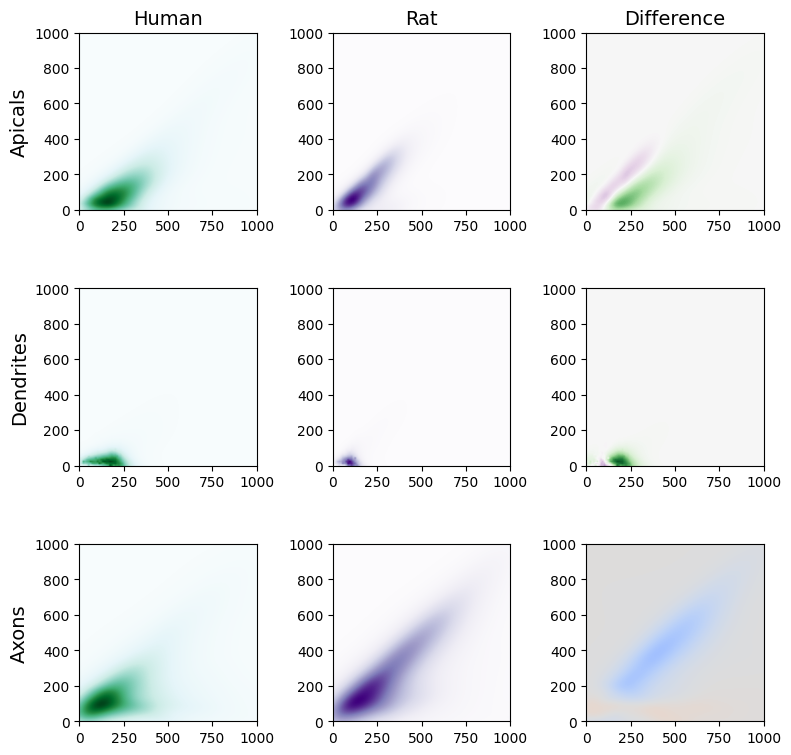

In [76]:
fig = plt.figure(figsize=(8,8))

bw_method = 0.2
xlim = (0, 1000)
ylim = (0, 1000)

ax1 = fig.add_subplot(331)
cmap = plt.cm.BuGn
Z1 = view.plot.persistence_image_average(phsH, aspect='equal', title='Human', xlabel='', ylabel='Apicals',
                                bw_method=bw_method, cmap=cmap, new_fig=False, xlim=xlim, ylim=ylim)[0]

ax2 = fig.add_subplot(332)
cmap = plt.cm.Purples
Z2 = view.plot.persistence_image_average(phsR, aspect='equal', title='Rat', xlabel='', ylabel='',
                                bw_method=bw_method, cmap=cmap, new_fig=False, xlim=xlim, ylim=ylim)[0]

ax3 = fig.add_subplot(333)
cmap = plt.cm.PRGn

_ = view.plot.persistence_image_diff(Z1, Z2, cmap=cmap, aspect='equal', title='Difference', xlabel='', ylabel='', 
                                     new_fig=False, xlim=xlim, ylim=ylim)

ax1 = fig.add_subplot(334)
cmap = plt.cm.BuGn
Z1 = view.plot.persistence_image_average(phsHD, aspect='equal', title='', xlabel='', ylabel='Dendrites',
                                bw_method=bw_method, cmap=cmap, new_fig=False, xlim=xlim, ylim=ylim)[0]
cmap = plt.cm.Purples
ax2 = fig.add_subplot(335)
Z2 = view.plot.persistence_image_average(phsRD, aspect='equal', title='', xlabel='', ylabel='',
                                bw_method=bw_method, cmap=cmap, new_fig=False, xlim=xlim, ylim=ylim)[0]

ax3 = fig.add_subplot(336)
cmap = plt.cm.PRGn

_ = view.plot.persistence_image_diff(Z1, Z2, cmap=cmap, aspect='equal', title='', xlabel='', ylabel='', 
                                     new_fig=False, xlim=xlim, ylim=ylim)
cmap = plt.cm.BuGn

ax1 = fig.add_subplot(337)
Z1 = view.plot.persistence_image_average(phsHA, aspect='equal', title='', xlabel='', ylabel='Axons', 
                                bw_method=bw_method, cmap=cmap, new_fig=False, xlim=xlim, ylim=ylim)[0]

cmap = plt.cm.Purples


ax2 = fig.add_subplot(338)
Z2 = view.plot.persistence_image_average(phsRA, aspect='equal', title='', xlabel='', ylabel='', 
                                bw_method=bw_method, cmap=cmap, new_fig=False, xlim=xlim, ylim=ylim)[0]

ax3 = fig.add_subplot(339)
cmap = plt.cm.coolwarm

_ = view.plot.persistence_image_diff(Z1, Z2, cmap=cmap, aspect='equal', title='', xlabel='', ylabel='', 
                                     new_fig=False, xlim=xlim, ylim=ylim)


plt.tight_layout()

#plt.savefig('../Figs/ForNatali/Topology.png')
#plt.savefig('../Figs/ForNatali/Topology.svg')
#plt.savefig('../Figs/ForNatali/Topology.eps')

